# PyTorch Implementation

## Step 1: Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

## Step 2: Create Dataset

In [2]:
X = torch.tensor([
    [0.,0.],
    [0.,1.],
    [1.,0.],
    [1.,1.]
])

y = torch.tensor([
    [0.],
    [1.],
    [1.],
    [0.]
])

## Step 3: Define the Neural Network

In [3]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        x = self.hidden(x)
        x = self.relu(x)

        x = self.output(x)
        x = self.sigmoid(x)

        return x

## Step 4: Create the Model

In [4]:
model = NeuralNetwork()

## Step 5: Define Loss Function

In [5]:
criterion = nn.BCELoss()

## Step 6: Define Optimizer

In [6]:
optimizer = optim.SGD(model.parameters(), lr=0.1)

## Step 7: Training Loop

In [7]:
train_losses = []
train_accuracies = []

In [8]:
epochs = 10000

for epoch in range(epochs):

    # Forward pass
    predictions = model(X)

    # Compute loss
    loss = criterion(predictions, y)

    # Compute accuracy
    predicted = (predictions >= 0.5).float()
    accuracy = (predicted == y).float().mean().item()

    # Store metrics
    train_losses.append(loss.item())
    train_accuracies.append(accuracy)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(
            f"Epoch {epoch}: "
            f"Loss = {loss.item():.4f}, "
            f"Accuracy = {accuracy:.4f}"
        )

Epoch 0: Loss = 0.6752, Accuracy = 0.5000
Epoch 1000: Loss = 0.0134, Accuracy = 1.0000
Epoch 2000: Loss = 0.0042, Accuracy = 1.0000
Epoch 3000: Loss = 0.0023, Accuracy = 1.0000
Epoch 4000: Loss = 0.0015, Accuracy = 1.0000
Epoch 5000: Loss = 0.0011, Accuracy = 1.0000
Epoch 6000: Loss = 0.0009, Accuracy = 1.0000
Epoch 7000: Loss = 0.0007, Accuracy = 1.0000
Epoch 8000: Loss = 0.0006, Accuracy = 1.0000
Epoch 9000: Loss = 0.0005, Accuracy = 1.0000


## Step 8: Make Predictions

In [9]:
with torch.no_grad():
    predictions = model(X)

print(predictions)

predicted_classes = (predictions >= 0.5).float()

print(predicted_classes)

tensor([[5.7293e-04],
        [9.9942e-01],
        [9.9963e-01],
        [3.7478e-04]])
tensor([[0.],
        [1.],
        [1.],
        [0.]])


## Visualization:

**Plot Loss Curve**

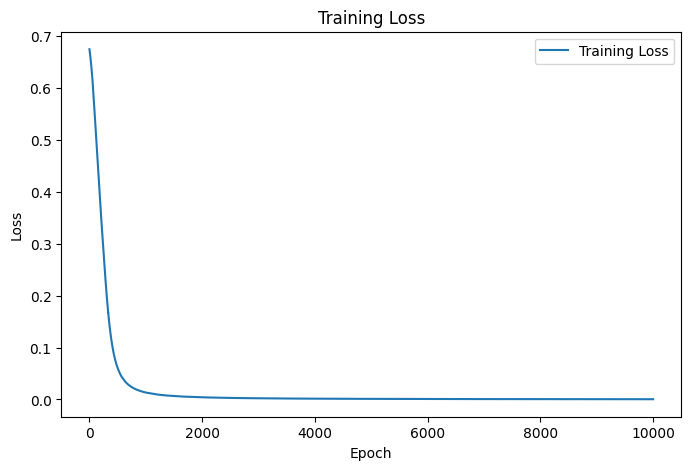

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

**Plot Accuracy Curve**

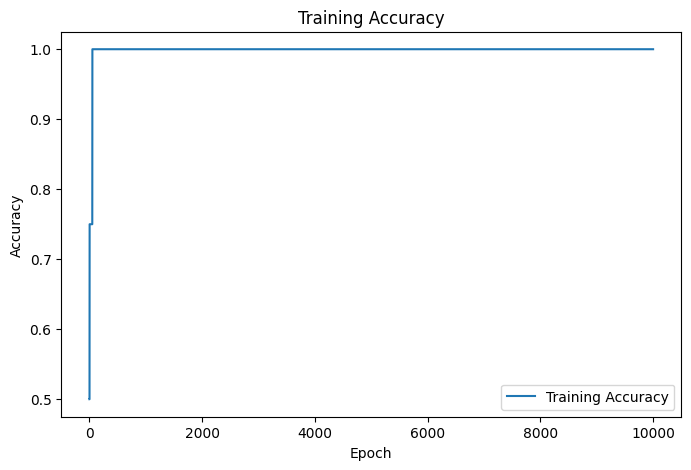

In [11]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Training Accuracy")

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

# TensorFlow Implementation:

## Step 1: Import TensorFlow

In [12]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

## Step 2: Dataset

In [13]:
import numpy as np

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

## Step 3: Build the Model

In [14]:
model = Sequential([
    Input(shape=(2,)),
    Dense(4, activation="relu"),
    Dense(1, activation="sigmoid")
])

## Step 4: Compile the Model

In [15]:
model.compile(
    optimizer="sgd",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Step 5: Train

In [16]:
history = model.fit(
    X,
    y,
    epochs=500,
    verbose=0
)

## Step 6: Predictions

In [17]:
predictions = model.predict(X)

print(predictions)

predicted_classes = (predictions >= 0.5).astype(int)

print(predicted_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[0.46680793]
 [0.57674783]
 [0.6044439 ]
 [0.43374354]]
[[0]
 [1]
 [1]
 [0]]


## Visualize:

**Plot Training Loss**

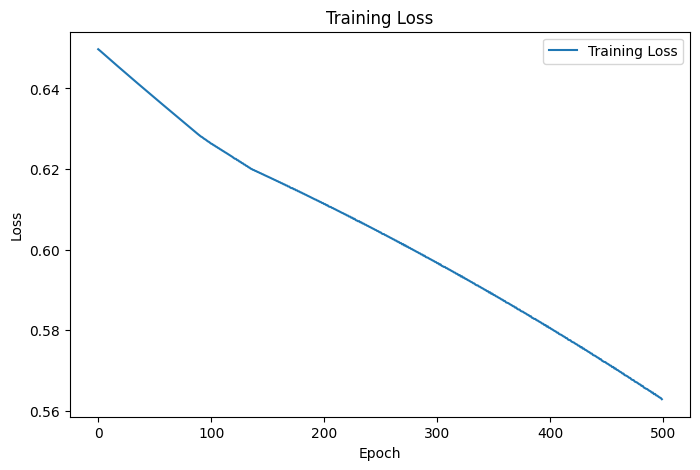

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

**Plot Training Accuracy**

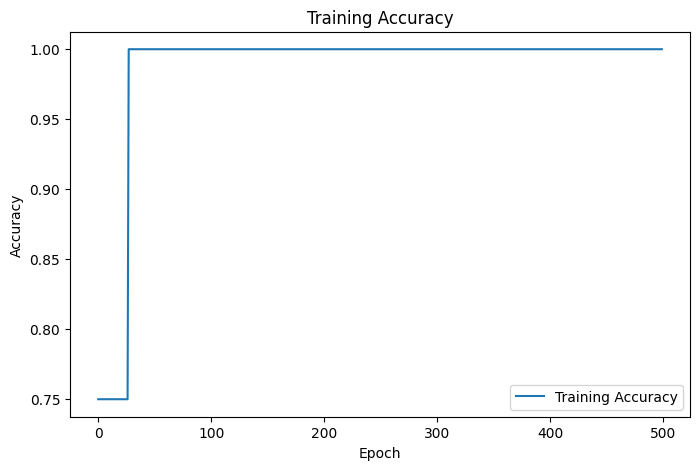

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()